In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "README.md").is_file() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "README.md").is_file():
    raise FileNotFoundError("Run this notebook from the project directory or one of its subdirectories.")


# EXP04 — iTransformer + Competition Aligned Weighted RMSE Loss

이 노트북은 물리 정제가 완료된 `train_final_physics.csv`를 입력으로 사용합니다.

### EXP04 핵심 개선점
1. **CompetitionAlignedRMSELoss 적용**: 대회 평가 척도와 1:1로 일치하는 가중치 RMSE 손실 함수 ($h_s < 1.5\text{m} \rightarrow 0.3$, $h_s \ge 1.5\text{m} \rightarrow 1.0$)
2. **물리 피처 풀 확장**: 파고 모멘텀(`hs_diff_1h`, `hs_diff_3h`), 파랑 에너지(`wave_energy`), 유효 순풍 에너지(`effective_wind_forcing`)
3. **대회 검증 규격 동기화**: `comp_rmse` ($h_s \ge 1.5\text{m}$) 및 78시간 독립 간격 평가

In [2]:
# ============================================================
# 0. SETUP & PACKAGES
# ============================================================
!pip -q install optuna

from pathlib import Path
import gc
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 28.0 MB/s eta 0:00:00
DEVICE: cuda
GPU: Tesla T4


In [3]:
# ============================================================
# 1. CONFIG
# ============================================================
DATA_PATH = Path(PROJECT_ROOT / "data" / "processed" / "train_final_physics_v4.csv")
TEST_CONTEXT_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_context.parquet")
TEST_INDEX_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_index.csv")
SUBMISSION_PATH = Path(PROJECT_ROOT / "submission" / "submission_exp14.csv")

EXP_DIR = PROJECT_ROOT / "artifacts" / "experiments" / "exp14"
EXP_DIR.mkdir(parents=True, exist_ok=True)

TIME_COL = "time"
STATION_COL = "station"

STEP_MINUTES = 10
STEPS_PER_HOUR = 6

INPUT_LEN = 289
LEAD_HOURS = [3, 6, 9, 12, 18, 24]
LEAD_STEPS = [h * STEPS_PER_HOUR for h in LEAD_HOURS]
MAX_LEAD = max(LEAD_STEPS)
N_TARGETS = len(LEAD_STEPS)

TRAIN_RATIO = 0.80

ABLATION_EPOCHS = 12
ABLATION_PATIENCE = 3

N_TRIALS = 30
OPTUNA_EPOCHS = 18
OPTUNA_PATIENCE = 4

FINAL_EPOCHS = 35
FINAL_PATIENCE = 6

# Lazy dataset: additional loader workers duplicate Python/NumPy state in RAM.
NUM_WORKERS = 0

print("INPUT_LEN:", INPUT_LEN)
print("LEADS:", LEAD_HOURS)


INPUT_LEN: 289
LEADS: [3, 6, 9, 12, 18, 24]


In [4]:
# ============================================================
# 2. LOAD DATA
# ============================================================
df = pd.read_csv(DATA_PATH, parse_dates=[TIME_COL])
df = df.sort_values([STATION_COL, TIME_COL]).reset_index(drop=True)

if "hs_original_observed" not in df.columns:
    df["hs_original_observed"] = df["hs"].notna().astype(np.int8)

print("shape:", df.shape)
print("stations:", df[STATION_COL].unique())
print("period:", df[TIME_COL].min(), "~", df[TIME_COL].max())

display(
    df.groupby(STATION_COL)
    .agg(
        rows=("hs", "size"),
        hs_missing=("hs", lambda s: s.isna().sum()),
    )
)


shape: (236304, 53)
stations: ['G-ORS' 'I-ORS' 'S-ORS']
period: 2024-01-01 00:00:00+09:00 ~ 2025-06-30 23:50:00+09:00


,rows,hs_missing
station,,
G-ORS,78768,0
I-ORS,78768,0
S-ORS,78768,0


In [5]:
# ============================================================
# 3. EXPANDED FEATURE GROUPS
# ============================================================
FEATURE_GROUPS = {
    "BASE_WAVE": ["hs", "tp", "hmax"],
    "WIND_BASIC": ["wspd", "gust", "u_wind", "v_wind"],
    "WAVE_MOMENTUM": ["hs_diff_1h", "hs_diff_3h", "hs_mean_6h", "hs_mean_12h", "hs_max_6h", "hs_max_12h"],
    "WAVE_DYNAMICS": ["wave_steepness", "wave_energy", "effective_wind_forcing", "u_wave", "v_wave"],
    "WIND_HISTORY": ["wspd_mean_6h", "wspd_mean_12h", "gust_max_6h", "gust_max_12h", "gust_minus_wspd"],
    "PRESSURE_TENDENCY": ["caph_change_3h", "caph_change_6h", "caph_change_12h"],
    "ALIGNMENT": ["wind_wave_alignment", "wind_wave_diff"],
    "ATMOS": ["airt", "relh", "caph"],
    "EXTENDED_WAVE": ["hmax_hs_ratio", "wave_energy_flux", "hs_std_6h", "hs_std_12h", "hs_range_6h", "hs_range_12h"],
    "EXTENDED_WIND": ["wspd_diff_1h", "wspd_diff_3h", "wspd_std_6h", "wspd_std_12h", "wind_cross_wave"],
    "EXTENDED_ATMOS": ["dew_point", "caph_anomaly_24h"],
}

for k, cols in list(FEATURE_GROUPS.items()):
    FEATURE_GROUPS[k] = [c for c in cols if c in df.columns]

print("=== FEATURE GROUPS ===")
for k, cols in FEATURE_GROUPS.items():
    print(k, "->", len(cols), cols)


=== FEATURE GROUPS ===
BASE_WAVE -> 3 ['hs', 'tp', 'hmax']
WIND_BASIC -> 4 ['wspd', 'gust', 'u_wind', 'v_wind']
WAVE_MOMENTUM -> 6 ['hs_diff_1h', 'hs_diff_3h', 'hs_mean_6h', 'hs_mean_12h', 'hs_max_6h', 'hs_max_12h']
WAVE_DYNAMICS -> 5 ['wave_steepness', 'wave_energy', 'effective_wind_forcing', 'u_wave', 'v_wave']
WIND_HISTORY -> 5 ['wspd_mean_6h', 'wspd_mean_12h', 'gust_max_6h', 'gust_max_12h', 'gust_minus_wspd']
PRESSURE_TENDENCY -> 3 ['caph_change_3h', 'caph_change_6h', 'caph_change_12h']
ALIGNMENT -> 2 ['wind_wave_alignment', 'wind_wave_diff']
ATMOS -> 3 ['airt', 'relh', 'caph']
EXTENDED_WAVE -> 6 ['hmax_hs_ratio', 'wave_energy_flux', 'hs_std_6h', 'hs_std_12h', 'hs_range_6h', 'hs_range_12h']
EXTENDED_WIND -> 5 ['wspd_diff_1h', 'wspd_diff_3h', 'wspd_std_6h', 'wspd_std_12h', 'wind_cross_wave']
EXTENDED_ATMOS -> 2 ['dew_point', 'caph_anomaly_24h']


In [6]:
# ============================================================
# 4. ABLATION SETS DEFINITION
# ============================================================

def uniq(seq):
    return list(dict.fromkeys(seq))


# ============================================================
# BASELINE
# ============================================================

FEATURE_SETS = {}


# ------------------------------------------------------------
# 1. 가장 기본
# ------------------------------------------------------------

FEATURE_SETS["BASE_WAVE"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
)


# ============================================================
# SINGLE GROUP ADDITION
# BASE_WAVE + 각 feature group
#
# → 어떤 그룹이 실제로 도움이 되는지 확인
# ============================================================

FEATURE_SETS["BASE_WAVE_WIND"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
    +
    FEATURE_GROUPS["WIND_BASIC"]
)


FEATURE_SETS["BASE_WAVE_MOMENTUM"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
    +
    FEATURE_GROUPS["WAVE_MOMENTUM"]
)


FEATURE_SETS["BASE_WAVE_DYNAMICS"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
    +
    FEATURE_GROUPS["WAVE_DYNAMICS"]
)


FEATURE_SETS["BASE_WAVE_WIND_HISTORY"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
    +
    FEATURE_GROUPS["WIND_HISTORY"]
)


FEATURE_SETS["BASE_WAVE_PRESSURE"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
    +
    FEATURE_GROUPS["PRESSURE_TENDENCY"]
)


FEATURE_SETS["BASE_WAVE_ALIGNMENT"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
    +
    FEATURE_GROUPS["ALIGNMENT"]
)


FEATURE_SETS["BASE_WAVE_ATMOS"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
    +
    FEATURE_GROUPS["ATMOS"]
)


# ============================================================
# IMPORTANT COMBINATIONS
# ============================================================

# ------------------------------------------------------------
# 파랑 자체 변화량 중심
# ------------------------------------------------------------

FEATURE_SETS["WAVE_CORE"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
    +
    FEATURE_GROUPS["WAVE_MOMENTUM"]
    +
    FEATURE_GROUPS["WAVE_DYNAMICS"]
)


# ------------------------------------------------------------
# 파랑 + 현재 바람
# ------------------------------------------------------------

FEATURE_SETS["WAVE_WIND"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
    +
    FEATURE_GROUPS["WIND_BASIC"]
    +
    FEATURE_GROUPS["WAVE_DYNAMICS"]
)


# ------------------------------------------------------------
# 파랑 + 바람 history
# ------------------------------------------------------------

FEATURE_SETS["WAVE_WIND_HISTORY"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
    +
    FEATURE_GROUPS["WIND_BASIC"]
    +
    FEATURE_GROUPS["WIND_HISTORY"]
)


# ------------------------------------------------------------
# 파랑 변화 + 바람
# ------------------------------------------------------------

FEATURE_SETS["WAVE_MOMENTUM_WIND"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
    +
    FEATURE_GROUPS["WAVE_MOMENTUM"]
    +
    FEATURE_GROUPS["WIND_BASIC"]
)


# ------------------------------------------------------------
# storm 관련
# 바람 + pressure + wave dynamics
# ------------------------------------------------------------

FEATURE_SETS["STORM_PHYSICS"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
    +
    FEATURE_GROUPS["WIND_BASIC"]
    +
    FEATURE_GROUPS["WIND_HISTORY"]
    +
    FEATURE_GROUPS["PRESSURE_TENDENCY"]
    +
    FEATURE_GROUPS["WAVE_DYNAMICS"]
)


# ------------------------------------------------------------
# directional interaction까지 포함
# ------------------------------------------------------------

FEATURE_SETS["STORM_DIRECTION"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"]
    +
    FEATURE_GROUPS["WIND_BASIC"]
    +
    FEATURE_GROUPS["WIND_HISTORY"]
    +
    FEATURE_GROUPS["PRESSURE_TENDENCY"]
    +
    FEATURE_GROUPS["WAVE_DYNAMICS"]
    +
    FEATURE_GROUPS["ALIGNMENT"]
)


# ============================================================
# 기존 compact physics 후보
# ============================================================

PHYSICS_OPTIMAL_FEATURES = [
    "hs",
    "tp",
    "hmax",

    "wspd",
    "u_wind",
    "v_wind",

    "hs_diff_1h",

    "wave_energy",
    "effective_wind_forcing",

    "u_wave",
    "v_wave",
]


FEATURE_SETS["PHYSICS_OPTIMAL_11"] = uniq(
    PHYSICS_OPTIMAL_FEATURES
)


# ============================================================
# ALL FEATURES
# 참고용
# ============================================================

FEATURE_SETS["ALL_FEATURES"] = uniq(
    sum(
        FEATURE_GROUPS.values(),
        []
    )
)

# EXP14: candidate sets that isolate each newly added physical family.
FEATURE_SETS["EXTENDED_WAVE_STATE"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"] + FEATURE_GROUPS["WAVE_MOMENTUM"]
    + FEATURE_GROUPS["WAVE_DYNAMICS"] + FEATURE_GROUPS["EXTENDED_WAVE"]
)
FEATURE_SETS["EXTENDED_WIND_FORCING"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"] + FEATURE_GROUPS["WIND_BASIC"]
    + FEATURE_GROUPS["WIND_HISTORY"] + FEATURE_GROUPS["ALIGNMENT"]
    + FEATURE_GROUPS["EXTENDED_WIND"]
)
FEATURE_SETS["EXTENDED_ATMOSPHERE"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"] + FEATURE_GROUPS["WIND_BASIC"]
    + FEATURE_GROUPS["PRESSURE_TENDENCY"] + FEATURE_GROUPS["ATMOS"]
    + FEATURE_GROUPS["EXTENDED_ATMOS"]
)
FEATURE_SETS["PHYSICS_EXTENDED"] = uniq(
    FEATURE_GROUPS["BASE_WAVE"] + FEATURE_GROUPS["WIND_BASIC"]
    + FEATURE_GROUPS["WAVE_MOMENTUM"] + FEATURE_GROUPS["WAVE_DYNAMICS"]
    + FEATURE_GROUPS["WIND_HISTORY"] + FEATURE_GROUPS["PRESSURE_TENDENCY"]
    + FEATURE_GROUPS["ALIGNMENT"] + FEATURE_GROUPS["EXTENDED_WAVE"]
    + FEATURE_GROUPS["EXTENDED_WIND"] + FEATURE_GROUPS["EXTENDED_ATMOS"]
)


# ============================================================
# REMOVE FEATURES NOT PRESENT IN DF
# ============================================================

for name, cols in list(FEATURE_SETS.items()):

    original_n = len(cols)

    FEATURE_SETS[name] = [
        c
        for c in cols
        if c in df.columns
    ]

    removed_n = (
        original_n
        -
        len(FEATURE_SETS[name])
    )

    if removed_n > 0:

        print(
            f"[WARN] {name}: "
            f"{removed_n} missing features removed"
        )


# ============================================================
# DEFAULT
# ============================================================

DEFAULT_FEATURE_SET = "PHYSICS_OPTIMAL_11"


# ============================================================
# DISPLAY
# ============================================================

feature_set_df = pd.DataFrame([
    {
        "feature_set": name,
        "n_features": len(cols),
        "features": ", ".join(cols),
    }
    for name, cols
    in FEATURE_SETS.items()
])


display(
    feature_set_df
    .sort_values(
        "n_features"
    )
    .reset_index(drop=True)
)

,feature_set,n_features,features
0,BASE_WAVE,3,"hs, tp, hmax"
1,BASE_WAVE_ALIGNMENT,5,"hs, tp, hmax, wind_wave_alignment, wind_wave_diff"
2,BASE_WAVE_PRESSURE,6,"hs, tp, hmax, caph_change_3h, caph_change_6h, ..."
3,BASE_WAVE_ATMOS,6,"hs, tp, hmax, airt, relh, caph"
4,BASE_WAVE_WIND,7,"hs, tp, hmax, wspd, gust, u_wind, v_wind"
5,BASE_WAVE_DYNAMICS,8,"hs, tp, hmax, wave_steepness, wave_energy, eff..."
6,BASE_WAVE_WIND_HISTORY,8,"hs, tp, hmax, wspd_mean_6h, wspd_mean_12h, gus..."
7,BASE_WAVE_MOMENTUM,9,"hs, tp, hmax, hs_diff_1h, hs_diff_3h, hs_mean_..."
8,PHYSICS_OPTIMAL_11,11,"hs, tp, hmax, wspd, u_wind, v_wind, hs_diff_1h..."
9,WAVE_WIND,12,"hs, tp, hmax, wspd, gust, u_wind, v_wind, wave..."


In [7]:
# ============================================================
# 5. SAMPLE BUILDING
# ============================================================
STATION_TO_ID = {station: i for i, station in enumerate(sorted(df[STATION_COL].unique()))}

def build_samples(frame, features, input_len=INPUT_LEN, lead_steps=LEAD_STEPS):
    """Store window metadata only; never materialize an (n_windows, L, F) array."""
    station_id, start_idx, end_idx = [], [], []
    origin_hs, origin_time = [], []
    x_by_station, hs_by_station = {}, {}
    max_lead = max(lead_steps)

    for station, g in frame.groupby(STATION_COL, sort=False):
        g = g.sort_values(TIME_COL).reset_index(drop=True)
        sid = STATION_TO_ID[station]
        # One 2D matrix per station is retained and sliced lazily by WaveDataset.
        Xv = g.loc[:, features].to_numpy(dtype=np.float32, copy=True)
        hsv = g["hs"].to_numpy(dtype=np.float32, copy=True)
        obs = g["hs_original_observed"].to_numpy(dtype=np.int8, copy=True)
        times = g[TIME_COL].to_numpy(copy=True)
        x_by_station[sid] = Xv
        hs_by_station[sid] = hsv
        dt = pd.Series(g[TIME_COL]).diff().dt.total_seconds().div(60).to_numpy()

        for e in range(input_len - 1, len(g) - max_lead):
            s = e - input_len + 1
            if not np.all(dt[s + 1:e + 1] == STEP_MINUTES):
                continue
            # This is a temporary view used only to validate the candidate window.
            if not np.isfinite(Xv[s:e + 1]).all():
                continue
            target_idx = np.asarray([e + step for step in lead_steps], dtype=np.int64)
            if not np.isfinite(hsv[target_idx]).all() or not np.all(obs[target_idx] == 1):
                continue
            if not np.isfinite(hsv[e]):
                continue

            station_id.append(sid)
            start_idx.append(s)
            end_idx.append(e)
            origin_hs.append(hsv[e])
            origin_time.append(times[e])

    return {
        "station_id": np.asarray(station_id, dtype=np.int64),
        "start_idx": np.asarray(start_idx, dtype=np.int64),
        "end_idx": np.asarray(end_idx, dtype=np.int64),
        "origin_hs": np.asarray(origin_hs, dtype=np.float32),
        "origin_time": np.asarray(origin_time, dtype="datetime64[ns]"),
        "X_by_station": x_by_station,
        "hs_by_station": hs_by_station,
        "source_frame": frame,
        "features": list(features),
        "n_features": len(features),
    }

WINDOW_META_KEYS = ("station_id", "start_idx", "end_idx", "origin_hs", "origin_time")

def chronological_split(samples, train_ratio=TRAIN_RATIO):
    times = pd.to_datetime(samples["origin_time"])
    cutoff = pd.Timestamp(pd.Series(times).quantile(train_ratio))

    def subset(mask):
        part = {key: samples[key][mask] for key in WINDOW_META_KEYS}
        part.update({
            "X_by_station": samples["X_by_station"],
            "hs_by_station": samples["hs_by_station"],
            "source_frame": samples["source_frame"],
            "features": samples["features"],
            "n_features": samples["n_features"],
            "split_cutoff": cutoff,
        })
        return part

    return subset(times <= cutoff), subset(times > cutoff), cutoff

def scale_samples(train, valid):
    # Fit directly on the original 2D train-period DataFrame, not on 3D windows.
    scaler = StandardScaler()
    train_rows = train["source_frame"][TIME_COL] <= train["split_cutoff"]
    scaler.fit(train["source_frame"].loc[train_rows, train["features"]])

    # train/valid share the same station matrices: transform each 2D matrix in place once.
    for Xv in train["X_by_station"].values():
        scaler.transform(Xv, copy=False)
    return dict(train), dict(valid), scaler


In [8]:
# ============================================================
# 6. USABLE WINDOW REPORT
# ============================================================
window_records = []
for feature_name, features in FEATURE_SETS.items():
    samples = build_samples(df, features)
    station_ids = samples["station_id"]
    record = {
        "feature_set": feature_name,
        "n_features": len(features),
        "usable_total": len(samples["end_idx"]),
        "origin_hs_ge_1.5": int((samples["origin_hs"] >= 1.5).sum()),
    }
    for station, sid in STATION_TO_ID.items():
        record[f"{station}_n"] = int((station_ids == sid).sum())
    window_records.append(record)

window_report = pd.DataFrame(window_records)
display(window_report.sort_values("usable_total", ascending=False))
window_report.to_csv(EXP_DIR / "usable_windows.csv", index=False)


,feature_set,n_features,usable_total,origin_hs_ge_1.5,G-ORS_n,I-ORS_n,S-ORS_n
0,BASE_WAVE,3,235008,49999,78336,78336,78336
1,BASE_WAVE_WIND,7,235008,49999,78336,78336,78336
2,BASE_WAVE_MOMENTUM,9,235008,49999,78336,78336,78336
3,BASE_WAVE_DYNAMICS,8,235008,49999,78336,78336,78336
4,BASE_WAVE_WIND_HISTORY,8,235008,49999,78336,78336,78336
5,BASE_WAVE_PRESSURE,6,235008,49999,78336,78336,78336
6,BASE_WAVE_ALIGNMENT,5,235008,49999,78336,78336,78336
7,BASE_WAVE_ATMOS,6,235008,49999,78336,78336,78336
8,WAVE_CORE,14,235008,49999,78336,78336,78336
9,WAVE_WIND,12,235008,49999,78336,78336,78336


In [9]:
# ============================================================
# 7. PYTORCH DATASET
# ============================================================
class WaveDataset(Dataset):
    def __init__(self, samples):
        self.X_by_station = samples["X_by_station"]
        self.hs_by_station = samples["hs_by_station"]
        self.station_id = samples["station_id"]
        self.start_idx = samples["start_idx"]
        self.end_idx = samples["end_idx"]
        self.origin_hs = samples["origin_hs"]
        self.lead_steps = np.asarray(LEAD_STEPS, dtype=np.int64)

    def __len__(self):
        return len(self.end_idx)

    def __getitem__(self, idx):
        sid = int(self.station_id[idx])
        start, end = int(self.start_idx[idx]), int(self.end_idx[idx])
        # Lazy views: only this batch's (289, n_features) windows are materialized.
        X = torch.from_numpy(self.X_by_station[sid][start:end + 1])
        y = torch.from_numpy(self.hs_by_station[sid][end + self.lead_steps])
        return X, y, torch.tensor(self.origin_hs[idx], dtype=torch.float32), torch.tensor(sid)

def make_loader(samples, batch_size=128, shuffle=False):
    ds = WaveDataset(samples)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=False,
        drop_last=False,
    )


In [10]:
# ============================================================
# 8. iTransformer MODEL DEFINITION
# ============================================================
class ITransformer(nn.Module):
    def __init__(self, seq_len, n_features, pred_len, d_model=64, n_heads=2, e_layers=3, dropout=0.25, d_ff=None):
        super().__init__()
        self.seq_len = seq_len
        self.n_features = n_features
        self.pred_len = pred_len
        if d_ff is None:
            d_ff = d_model * 4

        self.value_embedding = nn.Linear(seq_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=e_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_features * d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, pred_len),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.value_embedding(x)
        x = self.encoder(x)
        x = self.norm(x)
        out = self.head(x)
        return out


In [11]:
# ============================================================
# 9. METRICS & COMPETITION-ALIGNED LOSS
# ============================================================
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def lead_rmse(y_true, y_pred):
    return {f"rmse_{h}h": rmse(y_true[:, i], y_pred[:, i]) for i, h in enumerate(LEAD_HOURS)}

def competition_like_rmse(y_true, y_pred, origin_hs):
    mask = origin_hs >= 1.5
    if mask.sum() == 0:
        return np.nan, 0
    return rmse(y_true[mask], y_pred[mask]), int(mask.sum())

def competition_aligned_rmse(y_true, y_pred, origin_hs, threshold=1.5, high_weight=1.0, low_weight=0.3):
    diff_sq = (y_pred - y_true) ** 2
    weights = np.where(origin_hs >= threshold, high_weight, low_weight)[:, None]
    return float(np.sqrt(np.sum(weights * diff_sq) / np.sum(weights) + 1e-6))

def select_78h_separated_indices(times, station_ids, origin_hs, min_hours=78):
    selected = []
    times = pd.to_datetime(times)
    for sid in np.unique(station_ids):
        idx = np.where((station_ids == sid) & (origin_hs >= 1.5))[0]
        idx = idx[np.argsort(times[idx])]
        last_time = None
        for i in idx:
            t = times[i]
            if last_time is None or (t - last_time) >= pd.Timedelta(hours=min_hours):
                selected.append(i)
                last_time = t
    return np.asarray(selected, dtype=int)

def exact_competition_rmse(y_true, y_pred, samples):
    idx = select_78h_separated_indices(samples["origin_time"], samples["station_id"], samples["origin_hs"], min_hours=78)
    if len(idx) == 0:
        return np.nan, 0
    return rmse(y_true[idx], y_pred[idx]), len(idx)

# [EXP04 핵심] 대회 평가 지표 정렬 가중치 RMSE 손실함수
class CompetitionAlignedRMSELoss(nn.Module):
    def __init__(self, threshold=1.5, high_weight=1.0, low_weight=0.3):
        super().__init__()
        self.threshold = threshold
        self.high_weight = high_weight
        self.low_weight = low_weight

    def forward(self, pred, target, origin_hs):
        diff_sq = (pred - target) ** 2
        weights = torch.where(
            origin_hs >= self.threshold,
            torch.tensor(self.high_weight, device=pred.device),
            torch.tensor(self.low_weight, device=pred.device)
        ).unsqueeze(-1)
        weighted_mse = torch.sum(weights * diff_sq) / torch.sum(weights)
        return torch.sqrt(weighted_mse + 1e-6)


In [12]:
# ============================================================
# 10. TRAIN & EVAL FUNCTIONS
# ============================================================
def evaluate_model(model, loader):
    model.eval()
    preds, ys, origins = [], [], []
    with torch.no_grad():
        for X, y, origin_hs, _ in loader:
            X, y = X.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            pred = model(X)
            preds.append(pred.cpu().numpy())
            ys.append(y.cpu().numpy())
            origins.append(origin_hs.numpy())

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(preds)
    origin_hs = np.concatenate(origins)

    overall = rmse(y_true, y_pred)
    comp, comp_n = competition_like_rmse(y_true, y_pred, origin_hs)
    aligned = competition_aligned_rmse(y_true, y_pred, origin_hs)
    result = {
        "overall_rmse": overall,
        "comp_rmse": comp,
        "competition_aligned_rmse": aligned,
        "comp_valid_n": comp_n,
        **lead_rmse(y_true, y_pred),
    }
    return result, y_true, y_pred

def train_one_model(train_samples, valid_samples, params, max_epochs, patience, verbose=True):
    seed_everything(SEED)
    batch_size = params.get("batch_size", 128)
    train_loader = make_loader(train_samples, batch_size=batch_size, shuffle=True)
    valid_loader = make_loader(valid_samples, batch_size=batch_size, shuffle=False)

    model = ITransformer(
        seq_len=INPUT_LEN,
        n_features=train_samples["n_features"],
        pred_len=N_TARGETS,
        d_model=params["d_model"],
        n_heads=params["n_heads"],
        e_layers=params["e_layers"],
        dropout=params["dropout"],
        d_ff=params.get("d_ff", params["d_model"] * 4),
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    criterion = CompetitionAlignedRMSELoss(threshold=1.5, high_weight=1.0, low_weight=0.3)

    best_state = None
    best_score = np.inf
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for X, y, origin_hs, _ in train_loader:
            X, y, origin_hs = X.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True), origin_hs.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            pred = model(X)
            loss = criterion(pred, y, origin_hs)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        metrics, _, _ = evaluate_model(model, valid_loader)
        # Early stopping follows the same weighted RMSE as CompetitionAlignedRMSELoss.
        score = metrics["competition_aligned_rmse"]

        history.append({"epoch": epoch, "train_loss": float(np.mean(train_losses)), **metrics})
        if verbose:
            print(f"Epoch {epoch:02d} | train={np.mean(train_losses):.5f} | overall={metrics['overall_rmse']:.5f} | comp={metrics['comp_rmse']:.5f}")

        if score < best_score:
            best_score = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    final_metrics, y_true, y_pred = evaluate_model(model, valid_loader)
    return model, final_metrics, pd.DataFrame(history), y_true, y_pred


In [13]:
# ============================================================
# 11. FEATURE ABLATION STUDY - RAM SAFE VERSION
# ============================================================

import gc
import numpy as np
import pandas as pd
import torch


# ============================================================
# RAM-SAFE SETTINGS
# ============================================================

# Ablation은 feature 비교 목적이므로
# 전체 window를 다 쓰지 않고 최대 개수 제한
ABLATION_MAX_SAMPLES = 25000

# validation은 chronological split 유지
ABLATION_TRAIN_RATIO = TRAIN_RATIO


# ============================================================
# ROBUST CHRONOLOGICAL SPLIT
# ============================================================

def chronological_split(
    samples,
    train_ratio=ABLATION_TRAIN_RATIO
):

    times = pd.Series(
        pd.to_datetime(
            samples["origin_time"]
        )
    )

    source_tz = (
        samples["source_frame"][TIME_COL]
        .dt.tz
    )

    current_tz = times.dt.tz

    if source_tz is not None:

        if current_tz is None:
            times = (
                times
                .dt
                .tz_localize(source_tz)
            )

        else:
            times = (
                times
                .dt
                .tz_convert(source_tz)
            )

    elif current_tz is not None:

        times = (
            times
            .dt
            .tz_localize(None)
        )


    cutoff = times.quantile(
        train_ratio
    )


    train_mask = (
        times <= cutoff
    ).to_numpy()


    valid_mask = (
        times > cutoff
    ).to_numpy()


    def subset(mask):

        part = {}

        for key in WINDOW_META_KEYS:

            value = samples[key]

            # numpy array만 실제 subset
            part[key] = value[mask]


        # 아래는 큰 array 복사하지 않고 reference만 유지
        part.update({

            "X_by_station":
                samples["X_by_station"],

            "hs_by_station":
                samples["hs_by_station"],

            "source_frame":
                samples["source_frame"],

            "features":
                samples["features"],

            "n_features":
                samples["n_features"],

            "split_cutoff":
                cutoff,
        })

        return part


    return (
        subset(train_mask),
        subset(valid_mask),
        cutoff
    )


# ============================================================
# DOWNSAMPLE FOR ABLATION
#
# 시간 순서를 깨지 않으면서 전체 기간에서
# 균등하게 sample 선택
# ============================================================

def limit_ablation_samples(
    samples,
    max_samples=ABLATION_MAX_SAMPLES
):

    n = len(
        samples["end_idx"]
    )

    if n <= max_samples:
        return samples


    # 전체 시간대에서 균등 추출
    keep_idx = np.linspace(
        0,
        n - 1,
        max_samples,
        dtype=np.int64
    )


    reduced = {}

    for key in WINDOW_META_KEYS:
        reduced[key] = (
            samples[key][keep_idx]
        )


    reduced.update({

        "X_by_station":
            samples["X_by_station"],

        "hs_by_station":
            samples["hs_by_station"],

        "source_frame":
            samples["source_frame"],

        "features":
            samples["features"],

        "n_features":
            samples["n_features"],
    })


    return reduced


# ============================================================
# FIXED PARAMS
# Ablation에서는 모델도 조금 작게
# ============================================================

FIXED_PARAMS = {

    "d_model": 64,

    "n_heads": 2,

    "e_layers": 2,

    "dropout": 0.20,

    "lr": 3e-5,

    "weight_decay": 1e-5,

    "batch_size": 64,
}


# ============================================================
# FEATURE ABLATION
# ============================================================

ablation_records = []


for feature_name, features in FEATURE_SETS.items():

    print(
        "\n"
        + "=" * 90
    )

    print(
        "ABLATION:",
        feature_name,
        "|",
        len(features),
        "features"
    )


    # --------------------------------------------------------
    # 0. GPU/RAM CLEAN BEFORE START
    # --------------------------------------------------------

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    # --------------------------------------------------------
    # 1. BUILD SAMPLES
    # --------------------------------------------------------

    samples = build_samples(
        df,
        features
    )


    original_total = len(
        samples["end_idx"]
    )


    print(
        "original usable:",
        original_total
    )


    if original_total < 1000:

        print(
            "SKIP: too few samples"
        )

        del samples

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        continue


    # --------------------------------------------------------
    # 2. LIMIT SAMPLE COUNT
    # --------------------------------------------------------

    samples = limit_ablation_samples(
        samples,
        ABLATION_MAX_SAMPLES
    )


    n_total = len(
        samples["end_idx"]
    )


    print(
        "ablation usable:",
        n_total
    )


    # --------------------------------------------------------
    # 3. CHRONOLOGICAL SPLIT
    # --------------------------------------------------------

    train_s, valid_s, cutoff = (
        chronological_split(
            samples
        )
    )


    train_n = len(
        train_s["end_idx"]
    )

    valid_n = len(
        valid_s["end_idx"]
    )


    print(
        "cutoff:",
        cutoff
    )

    print(
        "train:",
        train_n,
        "| valid:",
        valid_n
    )


    if (
        train_n == 0
        or
        valid_n == 0
    ):

        print(
            "SKIP: empty split"
        )

        del (
            samples,
            train_s,
            valid_s,
        )

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        continue


    # --------------------------------------------------------
    # 4. SCALE
    # --------------------------------------------------------

    train_s, valid_s, scaler = (
        scale_samples(
            train_s,
            valid_s
        )
    )


    # samples 원본은 이제 필요 없음
    del samples

    gc.collect()


    # --------------------------------------------------------
    # 5. TRAIN
    # --------------------------------------------------------

    (
        model,
        metrics,
        history,
        y_true,
        y_pred
    ) = train_one_model(

        train_s,
        valid_s,

        params=FIXED_PARAMS,

        max_epochs=
            ABLATION_EPOCHS,

        patience=
            ABLATION_PATIENCE,

        verbose=False,
    )


    # --------------------------------------------------------
    # 6. EXACT COMPETITION SCORE
    # --------------------------------------------------------

    exact_comp, exact_n = (
        exact_competition_rmse(
            y_true,
            y_pred,
            valid_s
        )
    )


    # --------------------------------------------------------
    # 7. SAVE RESULT
    # --------------------------------------------------------

    record = {

        "feature_set":
            feature_name,

        "n_features":
            len(features),

        # 실제 usable 전체 수
        "original_total_n":
            original_total,

        # ablation에서 사용한 수
        "ablation_total_n":
            n_total,

        "train_n":
            train_n,

        "valid_n":
            valid_n,

        "cutoff":
            cutoff,

        **metrics,

        "exact_78h_comp_rmse":
            exact_comp,

        "exact_78h_n":
            exact_n,
    }


    ablation_records.append(
        record
    )


    print(
        "\nRESULT"
    )

    print(
        pd.Series(record)
    )


    # --------------------------------------------------------
    # 8. HARD MEMORY CLEANUP
    # --------------------------------------------------------

    del model
    del scaler

    del train_s
    del valid_s

    del history
    del y_true
    del y_pred

    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()

        # GPU IPC cache까지 정리
        try:
            torch.cuda.ipc_collect()
        except:
            pass


# ============================================================
# RESULTS
# ============================================================

ablation_df = pd.DataFrame(
    ablation_records
)


if len(ablation_df) == 0:

    raise RuntimeError(
        "No feature set completed ablation."
    )


sort_cols = []

if (
    "competition_aligned_rmse"
    in ablation_df.columns
):

    sort_cols.append(
        "competition_aligned_rmse"
    )


if (
    "overall_rmse"
    in ablation_df.columns
):

    sort_cols.append(
        "overall_rmse"
    )


if sort_cols:

    ablation_df = (
        ablation_df
        .sort_values(
            sort_cols,
            ascending=True
        )
        .reset_index(drop=True)
    )


print(
    "\n"
    + "=" * 90
)

print(
    "FEATURE ABLATION RESULT"
)

print(
    "=" * 90
)


display(
    ablation_df
)


# ============================================================
# SAVE
# ============================================================

ablation_df.to_csv(
    EXP_DIR / "feature_ablation.csv",
    index=False
)


print(
    "\nSaved:",
    EXP_DIR / "feature_ablation.csv"
)


ABLATION: BASE_WAVE | 3 features
original usable: 235008
ablation usable: 25000
cutoff: 2025-03-12 20:30:00+09:00
train: 20001 | valid: 4999

RESULT
feature_set                                 BASE_WAVE
n_features                                          3
original_total_n                               235008
ablation_total_n                                25000
train_n                                         20001
valid_n                                          4999
cutoff                      2025-03-12 20:30:00+09:00
overall_rmse                                 0.485107
comp_rmse                                     0.77343
competition_aligned_rmse                     1.373479
comp_valid_n                                      597
rmse_3h                                      0.320236
rmse_6h                                      0.403137
rmse_9h                                      0.451426
rmse_12h                                     0.497039
rmse_18h                                

,feature_set,n_features,original_total_n,ablation_total_n,train_n,valid_n,cutoff,overall_rmse,comp_rmse,competition_aligned_rmse,comp_valid_n,rmse_3h,rmse_6h,rmse_9h,rmse_12h,rmse_18h,rmse_24h,exact_78h_comp_rmse,exact_78h_n
0,EXTENDED_ATMOSPHERE,15,234579,25000,20002,4998,2025-03-13 01:20:00+09:00,0.460625,0.664605,1.253180,590,0.307511,0.385694,0.420713,0.469521,0.537005,0.586433,0.693336,40
1,ALL_FEATURES,44,234579,25000,20002,4998,2025-03-13 01:20:00+09:00,0.464468,0.675340,1.267211,590,0.301739,0.358863,0.422397,0.460641,0.567298,0.601763,0.683053,40
2,PHYSICS_OPTIMAL_11,11,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.465863,0.693258,1.283284,597,0.283258,0.366558,0.422805,0.470684,0.557190,0.613841,0.727289,42
3,WAVE_WIND,12,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.461713,0.705153,1.284721,597,0.286264,0.364802,0.424575,0.468560,0.547229,0.603967,0.695189,42
4,STORM_PHYSICS,20,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.472681,0.680085,1.285765,597,0.308829,0.372512,0.422153,0.485209,0.568649,0.607801,0.690596,42
5,PHYSICS_EXTENDED,41,234579,25000,20002,4998,2025-03-13 01:20:00+09:00,0.475802,0.685630,1.293871,590,0.297492,0.383129,0.424361,0.494174,0.572302,0.609275,0.707535,40
6,WAVE_MOMENTUM_WIND,13,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.466883,0.706729,1.294582,597,0.278795,0.377494,0.425159,0.470747,0.561531,0.608252,0.710281,42
7,BASE_WAVE_WIND,7,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.478343,0.706938,1.314214,597,0.303714,0.378406,0.433512,0.483304,0.568913,0.626307,0.717351,42
8,BASE_WAVE_DYNAMICS,8,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.472166,0.734345,1.323351,597,0.293799,0.385887,0.440574,0.484686,0.562166,0.597796,0.709165,42
9,WAVE_CORE,14,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.474729,0.741341,1.332721,597,0.289777,0.387251,0.445849,0.491612,0.563385,0.600336,0.718656,42



Saved: experiments/exp14/feature_ablation.csv


In [14]:
# ============================================================
# 12. CHOOSE BEST FEATURE SET
# ============================================================
assert len(ablation_df) > 0
max_comp_n = ablation_df["comp_valid_n"].max()
eligible = ablation_df[ablation_df["comp_valid_n"] >= 0.80 * max_comp_n].copy()
eligible = eligible.sort_values(["competition_aligned_rmse", "overall_rmse"])

BEST_FEATURE_NAME = eligible.iloc[0]["feature_set"]
BEST_FEATURES = FEATURE_SETS[BEST_FEATURE_NAME]

print("BEST FEATURE SET:", BEST_FEATURE_NAME)
print("N FEATURES:", len(BEST_FEATURES))
print(BEST_FEATURES)
display(eligible)


BEST FEATURE SET: EXTENDED_ATMOSPHERE
N FEATURES: 15
['hs', 'tp', 'hmax', 'wspd', 'gust', 'u_wind', 'v_wind', 'caph_change_3h', 'caph_change_6h', 'caph_change_12h', 'airt', 'relh', 'caph', 'dew_point', 'caph_anomaly_24h']


,feature_set,n_features,original_total_n,ablation_total_n,train_n,valid_n,cutoff,overall_rmse,comp_rmse,competition_aligned_rmse,comp_valid_n,rmse_3h,rmse_6h,rmse_9h,rmse_12h,rmse_18h,rmse_24h,exact_78h_comp_rmse,exact_78h_n
0,EXTENDED_ATMOSPHERE,15,234579,25000,20002,4998,2025-03-13 01:20:00+09:00,0.460625,0.664605,1.253180,590,0.307511,0.385694,0.420713,0.469521,0.537005,0.586433,0.693336,40
1,ALL_FEATURES,44,234579,25000,20002,4998,2025-03-13 01:20:00+09:00,0.464468,0.675340,1.267211,590,0.301739,0.358863,0.422397,0.460641,0.567298,0.601763,0.683053,40
2,PHYSICS_OPTIMAL_11,11,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.465863,0.693258,1.283284,597,0.283258,0.366558,0.422805,0.470684,0.557190,0.613841,0.727289,42
3,WAVE_WIND,12,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.461713,0.705153,1.284721,597,0.286264,0.364802,0.424575,0.468560,0.547229,0.603967,0.695189,42
4,STORM_PHYSICS,20,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.472681,0.680085,1.285765,597,0.308829,0.372512,0.422153,0.485209,0.568649,0.607801,0.690596,42
5,PHYSICS_EXTENDED,41,234579,25000,20002,4998,2025-03-13 01:20:00+09:00,0.475802,0.685630,1.293871,590,0.297492,0.383129,0.424361,0.494174,0.572302,0.609275,0.707535,40
6,WAVE_MOMENTUM_WIND,13,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.466883,0.706729,1.294582,597,0.278795,0.377494,0.425159,0.470747,0.561531,0.608252,0.710281,42
7,BASE_WAVE_WIND,7,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.478343,0.706938,1.314214,597,0.303714,0.378406,0.433512,0.483304,0.568913,0.626307,0.717351,42
8,BASE_WAVE_DYNAMICS,8,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.472166,0.734345,1.323351,597,0.293799,0.385887,0.440574,0.484686,0.562166,0.597796,0.709165,42
9,WAVE_CORE,14,235008,25000,20001,4999,2025-03-12 20:30:00+09:00,0.474729,0.741341,1.332721,597,0.289777,0.387251,0.445849,0.491612,0.563385,0.600336,0.718656,42


In [15]:
# ============================================================
# 13. PREPARE FIXED DATA FOR OPTUNA
# ============================================================
best_samples = build_samples(df, BEST_FEATURES)
train_samples, valid_samples, split_cutoff = chronological_split(best_samples)
train_samples, valid_samples, best_scaler = scale_samples(train_samples, valid_samples)

print("split cutoff:", split_cutoff)
print("train:", len(train_samples["end_idx"]))
print("valid:", len(valid_samples["end_idx"]))
print("high-wave valid:", int((valid_samples["origin_hs"] >= 1.5).sum()))


split cutoff: 2025-03-13 00:30:00+09:00
train: 187665
valid: 46914
high-wave valid: 5617


In [16]:
'''
# ============================================================
# 14. OPTUNA HYPERPARAMETER TUNING
# ============================================================
def objective(trial):
    d_model = trial.suggest_categorical("d_model", [64, 128, 256])
    valid_heads = [h for h in [2, 4, 8] if d_model % h == 0]
    params = {
        "d_model": d_model,
        "n_heads": trial.suggest_categorical("n_heads", valid_heads),
        "e_layers": trial.suggest_int("e_layers", 2, 4),
        "dropout": trial.suggest_float("dropout", 0.05, 0.35),
        "lr": trial.suggest_float("lr", 5e-6, 1e-4, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256]),
    }
    try:
        model, metrics, _, _, _ = train_one_model(
            train_samples, valid_samples, params=params, max_epochs=OPTUNA_EPOCHS, patience=OPTUNA_PATIENCE, verbose=False
        )
        trial.set_user_attr("overall_rmse", metrics["overall_rmse"])
        trial.set_user_attr("competition_aligned_rmse", metrics["competition_aligned_rmse"])
        trial.set_user_attr("comp_valid_n", metrics["comp_valid_n"])
        # Optimize the validation counterpart of CompetitionAlignedRMSELoss.
        score = metrics["competition_aligned_rmse"]
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return score
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()
            raise optuna.TrialPruned("CUDA OOM")
        raise

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=SEED), study_name="exp04_itransformer")
study.optimize(objective, n_trials=N_TRIALS, gc_after_trial=True)

print("BEST VALUE:", study.best_value)
print("BEST PARAMS:", study.best_params)
'''

'\n# ============================================================\n# 14. OPTUNA HYPERPARAMETER TUNING\n# ============================================================\ndef objective(trial):\n    d_model = trial.suggest_categorical("d_model", [64, 128, 256])\n    valid_heads = [h for h in [2, 4, 8] if d_model % h == 0]\n    params = {\n        "d_model": d_model,\n        "n_heads": trial.suggest_categorical("n_heads", valid_heads),\n        "e_layers": trial.suggest_int("e_layers", 2, 4),\n        "dropout": trial.suggest_float("dropout", 0.05, 0.35),\n        "lr": trial.suggest_float("lr", 5e-6, 1e-4, log=True),\n        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),\n        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256]),\n    }\n    try:\n        model, metrics, _, _, _ = train_one_model(\n            train_samples, valid_samples, params=params, max_epochs=OPTUNA_EPOCHS, patience=OPTUNA_PATIENCE, verbose=False\n        )\n        tr

### Using predefined BEST_PARAMS to skip Optuna

Based on the previous run, the best parameters are provided and will be used directly to train the final model.

In [17]:
BEST_PARAMS = {'d_model': 128, 'n_heads': 8, 'e_layers': 3, 'dropout': 0.3493749800552048, 'lr': 1.4153708812358071e-05, 'weight_decay': 1.3496870662716588e-05, 'batch_size': 128}
print("Using BEST_PARAMS:", BEST_PARAMS)

Using BEST_PARAMS: {'d_model': 128, 'n_heads': 8, 'e_layers': 3, 'dropout': 0.3493749800552048, 'lr': 1.4153708812358071e-05, 'weight_decay': 1.3496870662716588e-05, 'batch_size': 128}


In [19]:
'''
# ============================================================
# 15. OPTUNA RESULTS SUMMARY
# ============================================================
trials_df = study.trials_dataframe()
display(trials_df.sort_values("value").head(15))
trials_df.to_csv(EXP_DIR / "optuna_trials.csv", index=False)
with open(EXP_DIR / "best_params.json", "w", encoding="utf-8") as f:
    json.dump(study.best_params, f, indent=2, ensure_ascii=False)
'''

'\n# ============================================================\n# 15. OPTUNA RESULTS SUMMARY\n# ============================================================\ntrials_df = study.trials_dataframe()\ndisplay(trials_df.sort_values("value").head(15))\ntrials_df.to_csv(EXP_DIR / "optuna_trials.csv", index=False)\nwith open(EXP_DIR / "best_params.json", "w", encoding="utf-8") as f:\n    json.dump(study.best_params, f, indent=2, ensure_ascii=False)\n'

In [20]:
# ============================================================
# 16. FINAL MODEL RETRAINING
# ============================================================
# BEST_PARAMS = dict(study.best_params) # Comment out or remove this line
final_model, final_metrics, final_history, y_true, y_pred = train_one_model(
    train_samples, valid_samples, params=BEST_PARAMS, max_epochs=FINAL_EPOCHS, patience=FINAL_PATIENCE, verbose=True
)

exact_comp_rmse, exact_comp_n = exact_competition_rmse(y_true, y_pred, valid_samples)
final_metrics["exact_78h_comp_rmse"] = exact_comp_rmse
final_metrics["exact_78h_n"] = exact_comp_n

print("\n===== FINAL EXP04 METRICS =====")
display(pd.Series(final_metrics).to_frame("value"))
final_history.to_csv(EXP_DIR / "final_history.csv", index=False)
pd.DataFrame([final_metrics]).to_csv(EXP_DIR / "final_metrics.csv", index=False)


Epoch 01 | train=1.70042 | overall=0.45606 | comp=0.69380
Epoch 02 | train=1.46841 | overall=0.44148 | comp=0.67946
Epoch 03 | train=1.39991 | overall=0.44163 | comp=0.69072
Epoch 04 | train=1.35707 | overall=0.44732 | comp=0.69993
Epoch 05 | train=1.31713 | overall=0.44786 | comp=0.70619
Epoch 06 | train=1.28610 | overall=0.46147 | comp=0.71375
Epoch 07 | train=1.25954 | overall=0.45420 | comp=0.72134
Epoch 08 | train=1.23458 | overall=0.45771 | comp=0.72255

===== FINAL EXP04 METRICS =====


,value
overall_rmse,0.441476
comp_rmse,0.679463
competition_aligned_rmse,1.232447
comp_valid_n,5617.000000
rmse_3h,0.274412
rmse_6h,0.335617
rmse_9h,0.395395
rmse_12h,0.449262
rmse_18h,0.535090
rmse_24h,0.580491


,lead_hour,rmse
0,3,0.274412
1,6,0.335617
2,9,0.395395
3,12,0.449262
4,18,0.535090
5,24,0.580491


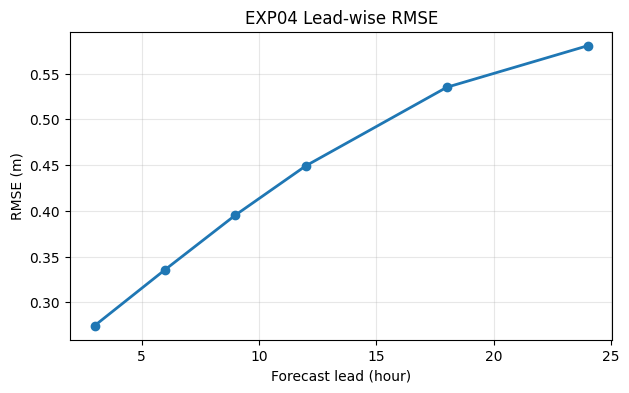

In [21]:
# ============================================================
# 17. LEAD-WISE RESULT PLOT
# ============================================================
lead_result = pd.DataFrame({
    "lead_hour": LEAD_HOURS,
    "rmse": [rmse(y_true[:, i], y_pred[:, i]) for i in range(N_TARGETS)],
})
display(lead_result)
lead_result.to_csv(EXP_DIR / "lead_rmse.csv", index=False)

plt.figure(figsize=(7, 4))
plt.plot(lead_result["lead_hour"], lead_result["rmse"], marker="o", color="#1f77b4", linewidth=2)
plt.xlabel("Forecast lead (hour)")
plt.ylabel("RMSE (m)")
plt.title("EXP04 Lead-wise RMSE")
plt.grid(True, alpha=0.3)
plt.show()


In [22]:
# ============================================================
# 18. SAVE MODEL + SCALER + METADATA
# ============================================================
import joblib
torch.save(
    {
        "model_state_dict": final_model.state_dict(),
        "features": BEST_FEATURES,
        "feature_set_name": BEST_FEATURE_NAME,
        "input_len": INPUT_LEN,
        "lead_hours": LEAD_HOURS,
        "params": BEST_PARAMS,
        "station_to_id": STATION_TO_ID,
        "metrics": final_metrics,
    },
    EXP_DIR / "best_model.pt",
)
joblib.dump(best_scaler, EXP_DIR / "scaler.pkl")

metadata = {
    "data_path": str(DATA_PATH),
    "feature_set_name": BEST_FEATURE_NAME,
    "features": BEST_FEATURES,
    "input_len": INPUT_LEN,
    "lead_hours": LEAD_HOURS,
    "split_cutoff": str(split_cutoff),
    "train_n": int(len(train_samples["end_idx"])),
    "valid_n": int(len(valid_samples["end_idx"])),
    "best_params": BEST_PARAMS,
    "metrics": {k: float(v) if isinstance(v, (float, np.floating)) else int(v) if isinstance(v, (int, np.integer)) else v for k, v in final_metrics.items()},
}
with open(EXP_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("Saved EXP04 artifacts to:", EXP_DIR.resolve())


Saved EXP04 artifacts to: /content/experiments/exp14


In [23]:
# ============================================================
# 19. TEST INFERENCE + SUBMISSION CREATION (EXP04)
# NaN-safe inference
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import torch


# ============================================================
# 0. TRAIN-BASED FALLBACK STATISTICS
# ============================================================

# df = EXP04 학습에 사용한 최종 training dataframe
# 반드시 train/physics feature 생성 셀 실행 후 사용

BASE_FALLBACK_COLS = [
    "tp",
    "wspd",
    "gust",
    "wdir",
    "wvdir",
    "airt",
    "relh",
    "caph",
]


station_medians = (
    df
    .groupby("station")[BASE_FALLBACK_COLS]
    .median()
)

global_medians = (
    df[BASE_FALLBACK_COLS]
    .median()
)


# ------------------------------------------------------------
# HMAX / HS ratio
# ------------------------------------------------------------

ratio_df = df[
    df["hs"].notna()
    &
    df["hmax"].notna()
    &
    (df["hs"] > 0)
].copy()

ratio_df["hmax_hs_ratio"] = (
    ratio_df["hmax"] / ratio_df["hs"]
)

ratio_df = ratio_df[
    ratio_df["hmax_hs_ratio"].between(1.0, 3.0)
]

station_hmax_ratio = (
    ratio_df
    .groupby("station")["hmax_hs_ratio"]
    .median()
)

global_hmax_ratio = float(
    ratio_df["hmax_hs_ratio"].median()
)


def get_station_median(station, col):

    value = np.nan

    if (
        station in station_medians.index
        and
        col in station_medians.columns
    ):
        value = station_medians.loc[
            station,
            col
        ]

    if not np.isfinite(value):
        value = global_medians[col]

    return float(value)


def get_hmax_ratio(station):

    if station in station_hmax_ratio.index:

        value = station_hmax_ratio.loc[
            station
        ]

        if np.isfinite(value):
            return float(value)

    return global_hmax_ratio


# ============================================================
# 1. TEST FEATURE ENGINEERING
# ============================================================

def add_test_features_exp04(context):

    feature_frames = []

    fallback_log = []

    required_cols = [
        "case_id",
        "station",
        "step_minute",
        "hs",
        "tp",
        "hmax",
        "wvdir",
        "wspd",
        "gust",
        "wdir",
        "airt",
        "relh",
        "caph",
    ]

    missing = [
        c
        for c in required_cols
        if c not in context.columns
    ]

    if missing:
        raise ValueError(
            f"test_context missing columns: {missing}"
        )


    for case_id, group in context.groupby(
        "case_id",
        sort=False
    ):

        g = (
            group
            .sort_values("step_minute")
            .copy()
        )

        st = g["station"].iloc[0]


        # ====================================================
        # INPUT LENGTH CHECK
        # ====================================================

        if len(g) != INPUT_LEN:

            raise ValueError(
                f"{case_id}: expected {INPUT_LEN} rows, "
                f"got {len(g)}"
            )


        # ====================================================
        # 2. INVALID VALUES -> NaN
        # ====================================================

        for col in [
            "hs",
            "tp",
            "hmax",
        ]:

            g.loc[
                g[col] <= 0,
                col
            ] = np.nan


        g.loc[
            g["wspd"] < 0,
            "wspd"
        ] = np.nan


        g.loc[
            g["gust"] < 0,
            "gust"
        ] = np.nan


        g.loc[
            ~g["relh"].between(0, 100),
            "relh"
        ] = np.nan


        g.loc[
            ~g["caph"].between(950, 1050),
            "caph"
        ] = np.nan


        # ====================================================
        # 3. CASE-INTERNAL INTERPOLATION
        # ====================================================

        num_cols = [
            "hs",
            "tp",
            "hmax",
            "wspd",
            "gust",
            "airt",
            "relh",
            "caph",
        ]


        g[num_cols] = (
            g[num_cols]
            .interpolate(
                method="linear",
                limit_direction="both"
            )
            .ffill()
            .bfill()
        )


        # ====================================================
        # 4. DIRECTION
        # ====================================================

        for col in [
            "wdir",
            "wvdir",
        ]:

            g[col] = (
                g[col]
                .ffill()
                .bfill()
            )

            # case 전체 NaN일 경우
            if g[col].isna().any():

                n_missing = int(
                    g[col].isna().sum()
                )

                value = get_station_median(
                    st,
                    col
                )

                g[col] = (
                    g[col]
                    .fillna(value)
                )

                fallback_log.append({
                    "case_id": case_id,
                    "station": st,
                    "column": col,
                    "n": n_missing,
                    "method": "station_median",
                })


        g["wdir"] %= 360.0
        g["wvdir"] %= 360.0


        # ====================================================
        # 5. HS
        #
        # hs는 핵심 signal이라 전체 NaN이면 중단
        # ====================================================

        if g["hs"].isna().all():

            raise ValueError(
                f"{case_id}: hs is entirely missing"
            )


        # 일부만 남으면 nearest context fallback
        if g["hs"].isna().any():

            n_missing = int(
                g["hs"].isna().sum()
            )

            g["hs"] = (
                g["hs"]
                .ffill()
                .bfill()
            )

            fallback_log.append({
                "case_id": case_id,
                "station": st,
                "column": "hs",
                "n": n_missing,
                "method": "context_ffill_bfill",
            })


        # ====================================================
        # 6. HMAX
        #
        # case 전체 NaN이어도
        # hs * train station ratio로 복원
        # ====================================================

        ratio = get_hmax_ratio(st)


        hmax_missing = (
            g["hmax"].isna()
            &
            g["hs"].notna()
        )


        if hmax_missing.any():

            n_missing = int(
                hmax_missing.sum()
            )

            g.loc[
                hmax_missing,
                "hmax"
            ] = (
                g.loc[
                    hmax_missing,
                    "hs"
                ]
                *
                ratio
            )

            fallback_log.append({
                "case_id": case_id,
                "station": st,
                "column": "hmax",
                "n": n_missing,
                "method": "hs_station_ratio",
            })


        # ====================================================
        # 7. REMAINING BASE VARIABLES
        #
        # case 전체 NaN -> train station median
        # ====================================================

        fallback_cols = [
            "tp",
            "wspd",
            "gust",
            "airt",
            "relh",
            "caph",
        ]


        for col in fallback_cols:

            if g[col].isna().any():

                n_missing = int(
                    g[col].isna().sum()
                )

                value = get_station_median(
                    st,
                    col
                )

                g[col] = (
                    g[col]
                    .fillna(value)
                )

                fallback_log.append({
                    "case_id": case_id,
                    "station": st,
                    "column": col,
                    "n": n_missing,
                    "method": "station_median",
                })


        # ====================================================
        # 8. BASE SANITY
        # ====================================================

        g["hs"] = g["hs"].clip(
            lower=0.01
        )

        g["tp"] = g["tp"].clip(
            lower=0.01
        )

        g["wspd"] = g["wspd"].clip(
            lower=0.0
        )

        g["gust"] = g["gust"].clip(
            lower=0.0
        )


        g["hmax"] = np.maximum(
            g["hmax"],
            g["hs"]
        )


        g["gust"] = np.maximum(
            g["gust"],
            g["wspd"]
        )


        # ====================================================
        # 9. WIND / WAVE VECTORS
        # ====================================================

        wdir_rad = np.deg2rad(
            g["wdir"]
        )

        wvdir_rad = np.deg2rad(
            g["wvdir"]
        )


        g["u_wind"] = (
            g["wspd"]
            *
            np.sin(wdir_rad)
        )


        g["v_wind"] = (
            g["wspd"]
            *
            np.cos(wdir_rad)
        )


        g["u_wave"] = (
            g["hs"]
            *
            np.sin(wvdir_rad)
        )


        g["v_wave"] = (
            g["hs"]
            *
            np.cos(wvdir_rad)
        )


        # ====================================================
        # 10. WIND/WAVE ALIGNMENT
        # ====================================================

        diff = (
            (
                g["wdir"]
                -
                g["wvdir"]
                +
                180
            )
            %
            360
            -
            180
        )


        g["wind_wave_diff"] = (
            np.abs(diff)
        )


        g["wind_wave_alignment"] = (
            np.cos(
                np.deg2rad(diff)
            )
        )


        # ====================================================
        # 11. WAVE MOMENTUM
        # ====================================================

        g["hs_diff_1h"] = (
            g["hs"]
            -
            g["hs"].shift(6)
        )


        g["hs_diff_3h"] = (
            g["hs"]
            -
            g["hs"].shift(18)
        )


        g["hs_mean_6h"] = (
            g["hs"]
            .rolling(
                36,
                min_periods=1
            )
            .mean()
        )


        g["hs_mean_12h"] = (
            g["hs"]
            .rolling(
                72,
                min_periods=1
            )
            .mean()
        )


        g["hs_max_6h"] = (
            g["hs"]
            .rolling(
                36,
                min_periods=1
            )
            .max()
        )


        g["hs_max_12h"] = (
            g["hs"]
            .rolling(
                72,
                min_periods=1
            )
            .max()
        )


        # ====================================================
        # 12. WIND HISTORY
        # ====================================================

        g["wspd_mean_6h"] = (
            g["wspd"]
            .rolling(
                36,
                min_periods=1
            )
            .mean()
        )


        g["wspd_mean_12h"] = (
            g["wspd"]
            .rolling(
                72,
                min_periods=1
            )
            .mean()
        )


        g["gust_max_6h"] = (
            g["gust"]
            .rolling(
                36,
                min_periods=1
            )
            .max()
        )


        g["gust_max_12h"] = (
            g["gust"]
            .rolling(
                72,
                min_periods=1
            )
            .max()
        )


        g["gust_minus_wspd"] = (
            g["gust"]
            -
            g["wspd"]
        )


        # ====================================================
        # 13. PRESSURE TENDENCY
        # ====================================================

        g["caph_change_3h"] = (
            g["caph"]
            -
            g["caph"].shift(18)
        )


        g["caph_change_6h"] = (
            g["caph"]
            -
            g["caph"].shift(36)
        )


        g["caph_change_12h"] = (
            g["caph"]
            -
            g["caph"].shift(72)
        )


        # ====================================================
        # 14. WAVE DYNAMICS
        # ====================================================

        wl = (
            1.56
            *
            (g["tp"] ** 2)
        )


        g["wave_steepness"] = (
            g["hs"]
            /
            np.maximum(
                wl,
                1.0
            )
        )


        g["wave_energy"] = (
            g["hs"] ** 2
        )


        g["effective_wind_forcing"] = (
            (g["wspd"] ** 2)
            *
            g["wind_wave_alignment"]
        )


        # ====================================================
        # 14B. EXP14 EXTENDED PHYSICS FEATURES
        # Uses the same formulas as train_v4 and only case context.
        # ====================================================
        g["hmax_hs_ratio"] = g["hmax"] / g["hs"].clip(lower=0.01)
        g["wave_energy_flux"] = (g["hs"] ** 2) * g["tp"]
        g["hs_std_6h"] = g["hs"].rolling(36, min_periods=36).std()
        g["hs_std_12h"] = g["hs"].rolling(72, min_periods=72).std()
        g["hs_range_6h"] = g["hs"].rolling(36, min_periods=36).max() - g["hs"].rolling(36, min_periods=36).min()
        g["hs_range_12h"] = g["hs"].rolling(72, min_periods=72).max() - g["hs"].rolling(72, min_periods=72).min()
        g["wspd_diff_1h"] = g["wspd"] - g["wspd"].shift(6)
        g["wspd_diff_3h"] = g["wspd"] - g["wspd"].shift(18)
        g["wspd_std_6h"] = g["wspd"].rolling(36, min_periods=36).std()
        g["wspd_std_12h"] = g["wspd"].rolling(72, min_periods=72).std()
        g["wind_cross_wave"] = g["wspd"] * np.sin(np.deg2rad(g["wdir"] - g["wvdir"]))
        rh_fraction = g["relh"].clip(lower=1e-3, upper=100.0) / 100.0
        gamma = np.log(rh_fraction) + (17.625 * g["airt"]) / (243.04 + g["airt"])
        g["dew_point"] = (243.04 * gamma) / (17.625 - gamma)
        g["caph_anomaly_24h"] = g["caph"] - g["caph"].rolling(144, min_periods=144).mean()


        # ====================================================
        # 15. INF -> NAN
        # ====================================================

        g = g.replace(
            [np.inf, -np.inf],
            np.nan
        )


        # ====================================================
        # 16. BEST FEATURES EXISTENCE CHECK
        # ====================================================

        missing_features = [
            c
            for c in BEST_FEATURES
            if c not in g.columns
        ]


        if missing_features:

            raise ValueError(
                f"{case_id}: missing features "
                f"{missing_features}"
            )


        # ====================================================
        # 17. DERIVED FEATURE INITIAL BOUNDARY
        #
        # shift(6), shift(18), shift(72) 등에서
        # 맨 앞부분에 생기는 NaN만 보정
        # ====================================================

        g[BEST_FEATURES] = (
            g[BEST_FEATURES]
            .bfill()
            .ffill()
        )


        # ====================================================
        # 18. FINAL FINITE CHECK
        # ====================================================

        X = g[
            BEST_FEATURES
        ].to_numpy(
            dtype=np.float32
        )


        if not np.isfinite(X).all():

            bad_cols = [
                col
                for col in BEST_FEATURES
                if not np.isfinite(
                    g[col]
                    .to_numpy(dtype=float)
                ).all()
            ]

            raise ValueError(
                f"{case_id}: non-finite features remain: "
                f"{bad_cols}"
            )


        feature_frames.append(g)


    # ========================================================
    # FALLBACK REPORT
    # ========================================================

    if fallback_log:

        fallback_df = pd.DataFrame(
            fallback_log
        )

        print(
            "\n===== INFERENCE FALLBACK SUMMARY ====="
        )

        display(
            fallback_df
            .groupby(
                ["column", "method"],
                as_index=False
            )
            .agg(
                n_cases=(
                    "case_id",
                    "nunique"
                ),
                n_values=(
                    "n",
                    "sum"
                ),
            )
        )


    return pd.concat(
        feature_frames,
        ignore_index=True
    )


# ============================================================
# 19. LOAD TEST
# ============================================================

test_context = pd.read_parquet(
    TEST_CONTEXT_PATH
)

test_index = pd.read_csv(
    TEST_INDEX_PATH
)


print(
    "test_context:",
    test_context.shape
)

print(
    "test_index:",
    test_index.shape
)


# ============================================================
# 20. ORIGINAL FULL-MISSING REPORT
# ============================================================

check_cols = [
    "hs",
    "tp",
    "hmax",
    "wvdir",
    "wspd",
    "gust",
    "wdir",
    "airt",
    "relh",
    "caph",
]


full_missing = (
    test_context
    .groupby("case_id")[check_cols]
    .apply(
        lambda x:
        x.isna().all()
    )
)


print(
    "\n===== ENTIRE CASE MISSING ====="
)

display(
    full_missing
    .sum()
    .sort_values(
        ascending=False
    )
)


# ============================================================
# 21. TEST FEATURE CREATION
# ============================================================

test_features = add_test_features_exp04(
    test_context
)


# ============================================================
# 22. WINDOWS
# ============================================================

case_order = (
    test_index["case_id"]
    .drop_duplicates()
    .tolist()
)


windows = []


for case_id in case_order:

    grp = (
        test_features[
            test_features["case_id"]
            ==
            case_id
        ]
        .sort_values(
            "step_minute"
        )
    )


    if len(grp) != INPUT_LEN:

        raise ValueError(
            f"{case_id}: "
            f"{len(grp)} rows "
            f"!= INPUT_LEN {INPUT_LEN}"
        )


    X = (
        grp[BEST_FEATURES]
        .to_numpy(
            dtype=np.float32
        )
    )


    if not np.isfinite(X).all():

        raise ValueError(
            f"{case_id}: "
            "NaN/Inf remains before scaling"
        )


    windows.append(X)


X_test_raw = np.stack(
    windows
)


print(
    "\nX_test_raw:",
    X_test_raw.shape
)


# ============================================================
# 23. SCALE
# ============================================================

X_test = (
    best_scaler
    .transform(
        X_test_raw.reshape(
            -1,
            len(BEST_FEATURES)
        )
    )
    .reshape(
        X_test_raw.shape
    )
    .astype(np.float32)
)


if not np.isfinite(
    X_test
).all():

    raise ValueError(
        "NaN/Inf created after scaling"
    )


# ============================================================
# 24. INFERENCE
# batch inference to reduce GPU memory
# ============================================================

final_model.eval()

pred_batches = []

INFER_BATCH_SIZE = 128


with torch.no_grad():

    for start in range(
        0,
        len(X_test),
        INFER_BATCH_SIZE
    ):

        xb = torch.from_numpy(
            X_test[
                start:
                start + INFER_BATCH_SIZE
            ]
        ).to(
            DEVICE
        )


        pred = (
            final_model(xb)
            .detach()
            .cpu()
            .numpy()
        )


        pred_batches.append(
            pred
        )


preds = np.concatenate(
    pred_batches,
    axis=0
)


if not np.isfinite(preds).all():

    raise ValueError(
        "Model prediction contains NaN/Inf"
    )


print(
    "prediction shape:",
    preds.shape
)


# ============================================================
# 25. BUILD SUBMISSION
# ============================================================

pred_rows = []


for case_id, row in zip(
    case_order,
    preds
):

    for lead_h, val in zip(
        LEAD_HOURS,
        row
    ):

        pred_rows.append({
            "case_id":
                case_id,

            "lead_h":
                lead_h,

            "hs_pred":
                float(val),
        })


pred_df = pd.DataFrame(
    pred_rows
)


submission = (
    test_index
    .merge(
        pred_df,
        on=[
            "case_id",
            "lead_h",
        ],
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# 26. FINAL PREDICTION SANITY
# ============================================================

if submission[
    "hs_pred"
].isna().any():

    bad = submission[
        submission["hs_pred"].isna()
    ]

    display(bad.head())

    raise ValueError(
        "Submission contains missing predictions"
    )


submission["hs_pred"] = (
    submission["hs_pred"]
    .clip(
        lower=0.0,
        upper=30.0
    )
)


# ============================================================
# 27. SAVE
# ============================================================

submission.to_csv(
    SUBMISSION_PATH,
    index=False,
    encoding="utf-8"
)


print(
    "\n"
    + "=" * 80
)

print(
    f"EXP04 SUBMISSION SAVED: "
    f"{SUBMISSION_PATH}"
)

print(
    "=" * 80
)

print(
    "rows:",
    len(submission)
)

print(
    "cases:",
    submission[
        "case_id"
    ].nunique()
)

print(
    "\nprediction stats:"
)

display(
    submission[
        "hs_pred"
    ]
    .describe()
)

display(
    submission.head(12)
)

test_context: (57800, 13)
test_index: (1200, 3)

===== ENTIRE CASE MISSING =====


,0
hmax,20
wspd,1
relh,1
airt,1
gust,1
wdir,1
caph,1
hs,0
tp,0
wvdir,0



===== INFERENCE FALLBACK SUMMARY =====


,column,method,n_cases,n_values
0,airt,station_median,1,289
1,caph,station_median,1,289
2,gust,station_median,1,289
3,hmax,hs_station_ratio,20,5780
4,relh,station_median,1,289
5,wdir,station_median,1,289
6,wspd,station_median,1,289



X_test_raw: (200, 289, 15)
prediction shape: (200, 6)

EXP04 SUBMISSION SAVED: submission_exp14.csv
rows: 1200
cases: 200

prediction stats:


,hs_pred
count,1200.000000
mean,1.585062
std,0.566668
min,0.256784
25%,1.186871
50%,1.572349
75%,1.933972
max,4.321314


,case_id,station,lead_h,hs_pred
0,C0001,S-ORS,3,1.168948
1,C0001,S-ORS,6,0.947572
2,C0001,S-ORS,9,0.916110
3,C0001,S-ORS,12,0.961536
4,C0001,S-ORS,18,0.651082
5,C0001,S-ORS,24,0.700075
6,C0002,I-ORS,3,1.461295
7,C0002,I-ORS,6,1.418142
8,C0002,I-ORS,9,1.307672
9,C0002,I-ORS,12,1.249605
